# SVD Eigenfaces Analysis

## Overview
This notebook performs Singular Value Decomposition (SVD) on video frames to extract eigenfaces in both color and grayscale modes. It compares two SVD approaches:
- **Concatenated Format**: All pixel values treated as one feature vector
- **Native Format**: Per-channel SVD preserving color structure

## Load Video and Prepare Data

In [2]:
import cv2
import numpy as np
import os

# Configuration
video_path = r"C:\Users\braid\OneDrive\Desktop\Normal speed.mp4"
output_dir = r"C:\Users\braid\OneDrive\Desktop\SVD_eigenfaces"
os.makedirs(output_dir, exist_ok=True)

scale = 0.25  # Scale down factor (adjust as needed)

# Load video
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise Exception("Could not open video.")

frames_color = []
frames_gray = []

print("Loading video frames...")
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Scale down
    H0, W0 = frame.shape[:2]
    new_H = int(H0 * scale)
    new_W = int(W0 * scale)
    frame_small = cv2.resize(frame, (new_W, new_H))

    # Store color and grayscale
    frames_color.append(frame_small.flatten())
    frame_gray = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY)
    frames_gray.append(frame_gray.flatten())

cap.release()

H, W = new_H, new_W
num_frames = len(frames_color)
print(f"✓ Loaded {num_frames} frames at {H}x{W} resolution")

Loading video frames...
✓ Loaded 915 frames at 270x480 resolution


## Perform SVD - Concatenated Approach

In [3]:
print("CONCATENATED FORMAT SVD")

# COLOR - Concatenated Format
X = np.array(frames_color).T  # (H*W*3, num_frames)
pixels, num_frames_color = X.shape
print(f"\n[COLOR] Shape: {X.shape}")

mean_vec = np.mean(X, axis=1, keepdims=True)
X_centered = X - mean_vec

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
print(f"  U shape: {U.shape}")
print(f"  S shape: {S.shape}")
print(f"  Vt shape: {Vt.shape}")
print(f"  Top 5 singular values: {S[:5]}")

# GRAYSCALE - Concatenated Format
X_gray = np.array(frames_gray).T  # (H*W, num_frames)
pixels_gray, num_frames_gray = X_gray.shape
print(f"\n[GRAYSCALE] Shape: {X_gray.shape}")

mean_vec_gray = np.mean(X_gray, axis=1, keepdims=True)
X_centered_gray = X_gray - mean_vec_gray

U_gray, S_gray, Vt_gray = np.linalg.svd(X_centered_gray, full_matrices=False)
print(f"  U shape: {U_gray.shape}")
print(f"  S shape: {S_gray.shape}")
print(f"  Vt shape: {Vt_gray.shape}")
print(f"  Top 5 singular values: {S_gray[:5]}")

CONCATENATED FORMAT SVD

[COLOR] Shape: (388800, 915)
  U shape: (388800, 915)
  S shape: (915,)
  Vt shape: (915, 915)
  Top 5 singular values: [87628.79185601 51871.38191005 49015.7793024  45215.36413974
 36030.05836162]

[GRAYSCALE] Shape: (129600, 915)
  U shape: (129600, 915)
  S shape: (915,)
  Vt shape: (915, 915)
  Top 5 singular values: [52114.40916869 30096.34711582 28470.53166299 26309.49327634
 21005.14208499]


## Perform SVD Unsubtracted Mean

In [4]:
# GRAYSCALE - Concatenated Format - Unsubtracted Mean
X_gray = np.array(frames_gray).T  # (H*W, num_frames)
pixels_gray, num_frames_gray = X_gray.shape
print(f"\n[GRAYSCALE Unsubtracted Mean] Shape: {X_gray.shape}")

mean_vec_gray = np.mean(X_gray, axis=1, keepdims=True)
X_centered_gray = X_gray # No mean subtraction

U_gray_Unsubtracted_Mean, S_gray_Unsubtracted_Mean, Vt_gray_Unsubtracted_Mean = np.linalg.svd(X_centered_gray, full_matrices=False)
print(f"  U shape: {U_gray_Unsubtracted_Mean.shape}")
print(f"  S shape: {S_gray_Unsubtracted_Mean.shape}")
print(f"  Vt shape: {Vt_gray_Unsubtracted_Mean.shape}")
print(f"  Top 5 singular values: {S_gray_Unsubtracted_Mean[:5]}")


[GRAYSCALE Unsubtracted Mean] Shape: (129600, 915)
  U shape: (129600, 915)
  S shape: (915,)
  Vt shape: (915, 915)
  Top 5 singular values: [1437770.34998114   52114.03574205   30094.99721135   28464.70700549
   26271.00098777]


## Perform SVD - Native Approach

In [5]:
print("NATIVE FORMAT SVD (Per-Channel)")

# COLOR - Native Format (per-channel)
frames_color_native = np.array(frames_color).reshape(num_frames, H, W, 3)
frames_color_native = frames_color_native.transpose(1, 2, 0, 3)  # (H, W, num_frames, 3)
frames_color_native_reshaped = frames_color_native.reshape(-1, num_frames, 3)  # (H*W, num_frames, 3)
print(f"\n[COLOR] Native shape: {frames_color_native_reshaped.shape}")

# Center the data for each channel
frames_color_native_centered = np.zeros_like(frames_color_native_reshaped)
for c in range(3):
    mean_c = np.mean(frames_color_native_reshaped[:, :, c], axis=1, keepdims=True)
    # Shape: (H*W, 1) - mean per pixel across frames
    frames_color_native_centered[:, :, c] = frames_color_native_reshaped[:, :, c] - mean_c
    
# SVD for each color channel
U_native_r, S_native_r, Vt_native_r = np.linalg.svd(frames_color_native_centered[:, :, 0], full_matrices=False)
U_native_g, S_native_g, Vt_native_g = np.linalg.svd(frames_color_native_centered[:, :, 1], full_matrices=False)
U_native_b, S_native_b, Vt_native_b = np.linalg.svd(frames_color_native_centered[:, :, 2], full_matrices=False)

print(f"  Red   - U: {U_native_r.shape}, S: {S_native_r.shape}, Top 5 SV: {S_native_r[:5]}")
print(f"  Green - U: {U_native_g.shape}, S: {S_native_g.shape}, Top 5 SV: {S_native_g[:5]}")
print(f"  Blue  - U: {U_native_b.shape}, S: {S_native_b.shape}, Top 5 SV: {S_native_b[:5]}")



NATIVE FORMAT SVD (Per-Channel)

[COLOR] Native shape: (129600, 915, 3)
  Red   - U: (129600, 915), S: (915,), Top 5 SV: [530977.76395655 183151.98904474 165284.02749172 104164.88208799
  93685.88738669]
  Green - U: (129600, 915), S: (915,), Top 5 SV: [453547.6816966  170989.05712701 145873.37379968  91594.97035203
  77408.68200947]
  Blue  - U: (129600, 915), S: (915,), Top 5 SV: [653684.85658704 176902.3397526  170717.64714047 102430.32677597
  96120.42594139]


## Save Eigenfaces - Concatenated Approach

In [6]:
print("SAVING EIGENFACES - CONCATENATED FORMAT")

# Save COLOR eigenfaces
print("\nSaving COLOR eigenfaces (Concatenated)...")
for i in range(5):
    ef = U[:, i].reshape(H, W, 3)
    ef_norm = np.zeros_like(ef)
    
    # Normalize each channel independently
    for c in range(3):
        ef_norm[..., c] = cv2.normalize(ef[..., c], None, 0, 255, cv2.NORM_MINMAX)
    
    ef_norm = ef_norm.astype(np.uint8)
    filename = f"{output_dir}\\Eigenface_Concat_Color_{i+1}.png"
    cv2.imwrite(filename, ef_norm)
    print(f"  ✓ Eigenface_Concat_Color_{i+1}.png")

print(f"✓ Saved to {output_dir}")

SAVING EIGENFACES - CONCATENATED FORMAT

Saving COLOR eigenfaces (Concatenated)...
  ✓ Eigenface_Concat_Color_1.png
  ✓ Eigenface_Concat_Color_2.png
  ✓ Eigenface_Concat_Color_3.png
  ✓ Eigenface_Concat_Color_4.png
  ✓ Eigenface_Concat_Color_5.png
✓ Saved to C:\Users\braid\OneDrive\Desktop\SVD_eigenfaces


## Save Eigenfaces - Native Approach

In [7]:
print("SAVING EIGENFACES - NATIVE FORMAT (Per-Channel)")

# Save COLOR eigenfaces
print("\nSaving COLOR eigenfaces (Native - per-channel)...")
for i in range(5):
    ef_native = np.zeros((H, W, 3), dtype=np.float32)
    ef_native[..., 0] = U_native_r[:, i].reshape(H, W)  # Red
    ef_native[..., 1] = U_native_g[:, i].reshape(H, W)  # Green
    ef_native[..., 2] = U_native_b[:, i].reshape(H, W)  # Blue
    
    ef_native_norm = np.zeros_like(ef_native)
    for c in range(3):
        ef_native_norm[..., c] = cv2.normalize(ef_native[..., c], None, 0, 255, cv2.NORM_MINMAX)
    
    ef_native_norm = ef_native_norm.astype(np.uint8)
    filename = f"{output_dir}\\Eigenface_Native_Color_{i+1}.png"
    cv2.imwrite(filename, ef_native_norm)
    print(f"  ✓ Eigenface_Native_Color_{i+1}.png")

print(f"✓ Saved to {output_dir}")

SAVING EIGENFACES - NATIVE FORMAT (Per-Channel)

Saving COLOR eigenfaces (Native - per-channel)...
  ✓ Eigenface_Native_Color_1.png
  ✓ Eigenface_Native_Color_2.png
  ✓ Eigenface_Native_Color_3.png
  ✓ Eigenface_Native_Color_4.png
  ✓ Eigenface_Native_Color_5.png
✓ Saved to C:\Users\braid\OneDrive\Desktop\SVD_eigenfaces


## Save Grayscale Eigenfaces

In [8]:
print("SAVING EIGENFACES - GRAYSCALE")

print("\nSaving GRAYSCALE eigenfaces...")
print("(Note: Same for both approaches - only one channel)\n")

for i in range(5):
    ef_gray = U_gray[:, i].reshape(H, W)
    ef_gray_norm = cv2.normalize(ef_gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    filename = f"{output_dir}\\Eigenface_Gray_{i+1}.png"
    cv2.imwrite(filename, ef_gray_norm)
    print(f"  ✓ Eigenface_Gray_{i+1}.png")

print(f"✓ Saved to {output_dir}")

SAVING EIGENFACES - GRAYSCALE

Saving GRAYSCALE eigenfaces...
(Note: Same for both approaches - only one channel)

  ✓ Eigenface_Gray_1.png
  ✓ Eigenface_Gray_2.png
  ✓ Eigenface_Gray_3.png
  ✓ Eigenface_Gray_4.png
  ✓ Eigenface_Gray_5.png
✓ Saved to C:\Users\braid\OneDrive\Desktop\SVD_eigenfaces


## Save Gray Scale Unsubtracted Mean

In [9]:
print("SAVING EIGENFACES - GRAYSCALE")

print("\nSaving GRAYSCALE eigenfaces...")
print("(Note: Same for both approaches - only one channel)\n")

for i in range(5):
    ef_gray = U_gray_Unsubtracted_Mean[:, i].reshape(H, W)
    ef_gray_norm = cv2.normalize(ef_gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    filename = f"{output_dir}\\Eigenface_Gray_Unsubtracted_Mean{i+1}.png"
    cv2.imwrite(filename, ef_gray_norm)
    print(f"  ✓ Eigenface_Gray_Unsubtracted_Mean{i+1}.png")

print(f"✓ Saved to {output_dir}")

SAVING EIGENFACES - GRAYSCALE

Saving GRAYSCALE eigenfaces...
(Note: Same for both approaches - only one channel)

  ✓ Eigenface_Gray_Unsubtracted_Mean1.png
  ✓ Eigenface_Gray_Unsubtracted_Mean2.png
  ✓ Eigenface_Gray_Unsubtracted_Mean3.png
  ✓ Eigenface_Gray_Unsubtracted_Mean4.png
  ✓ Eigenface_Gray_Unsubtracted_Mean5.png
✓ Saved to C:\Users\braid\OneDrive\Desktop\SVD_eigenfaces


## Scree Plots 

CREATING AND SAVING SCREE PLOTS
✓ Saved: Scree_Plot_01a_Concat_Color_Line.png


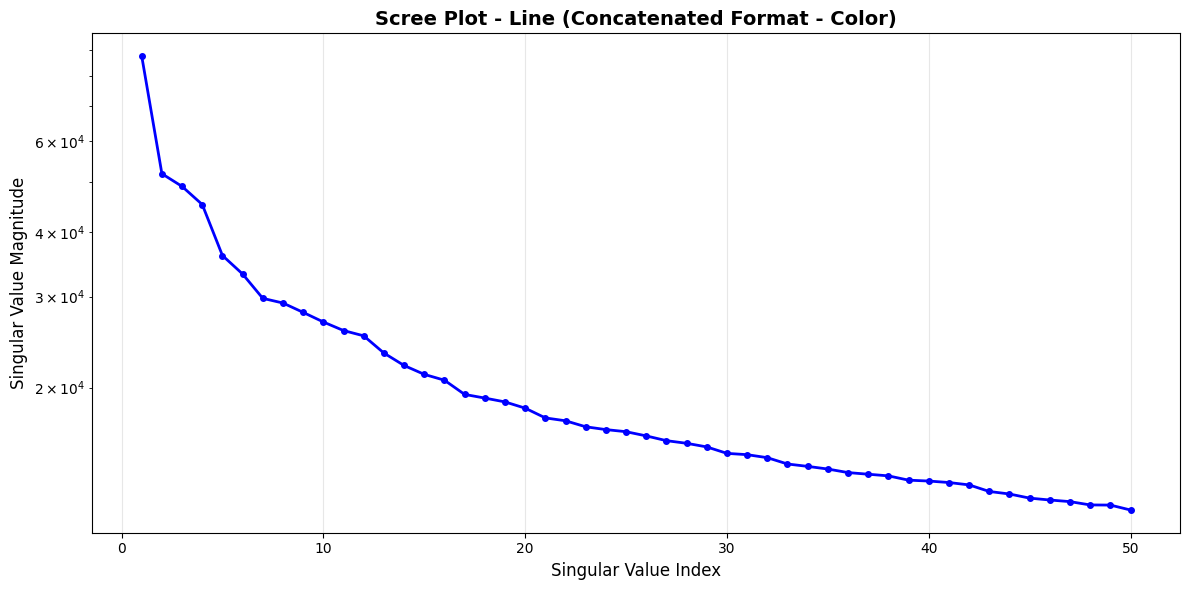

✓ Saved: Scree_Plot_01b_Concat_Color_Bar.png


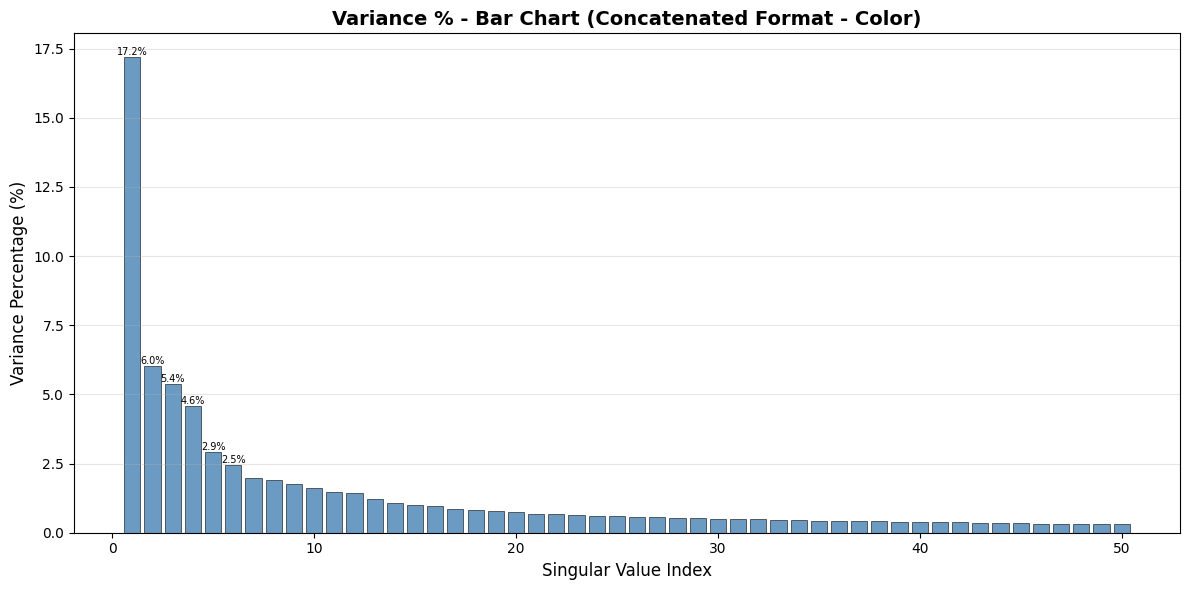

✓ Saved: Scree_Plot_02a_Concat_Gray_MeanSub_Line.png


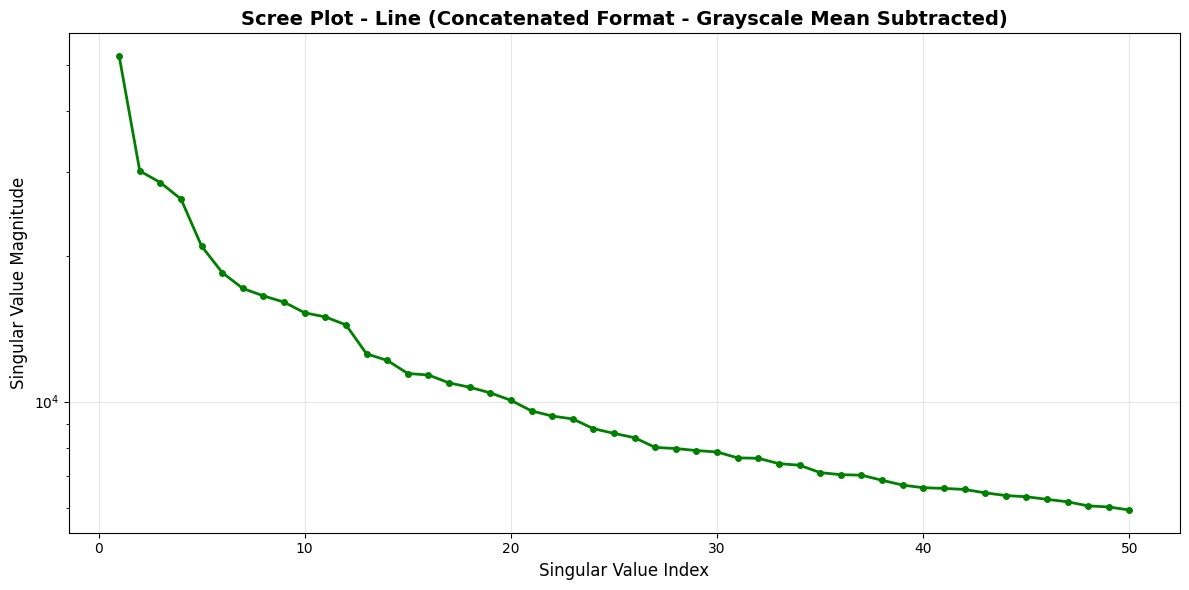

✓ Saved: Scree_Plot_02b_Concat_Gray_MeanSub_Bar.png


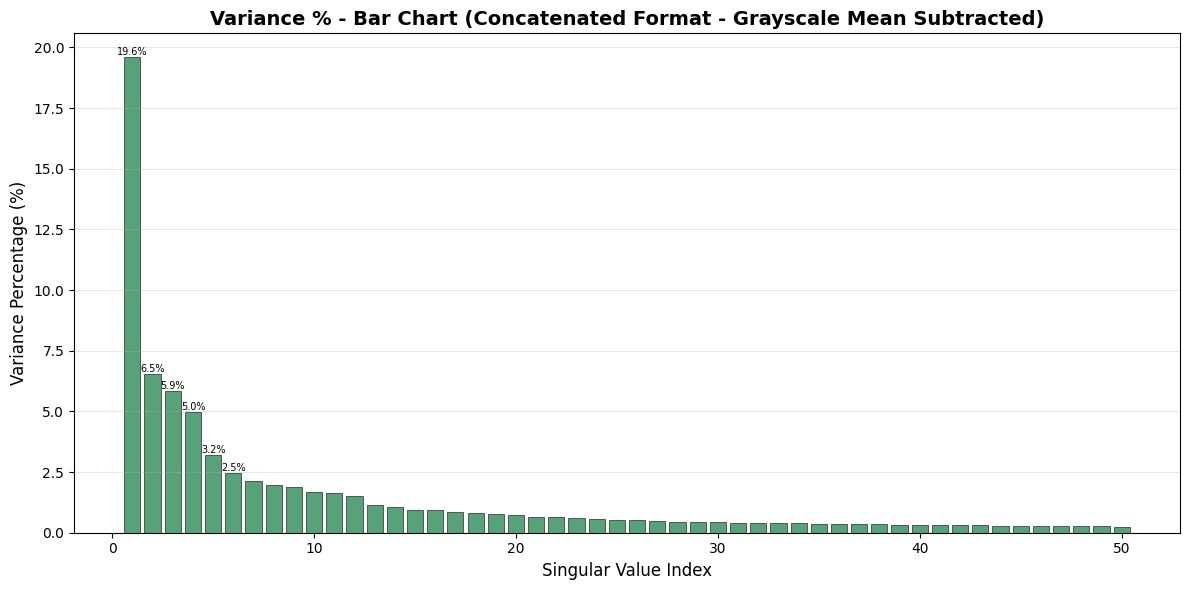

✓ Saved: Scree_Plot_03a_Concat_Gray_Unsub_Line.png


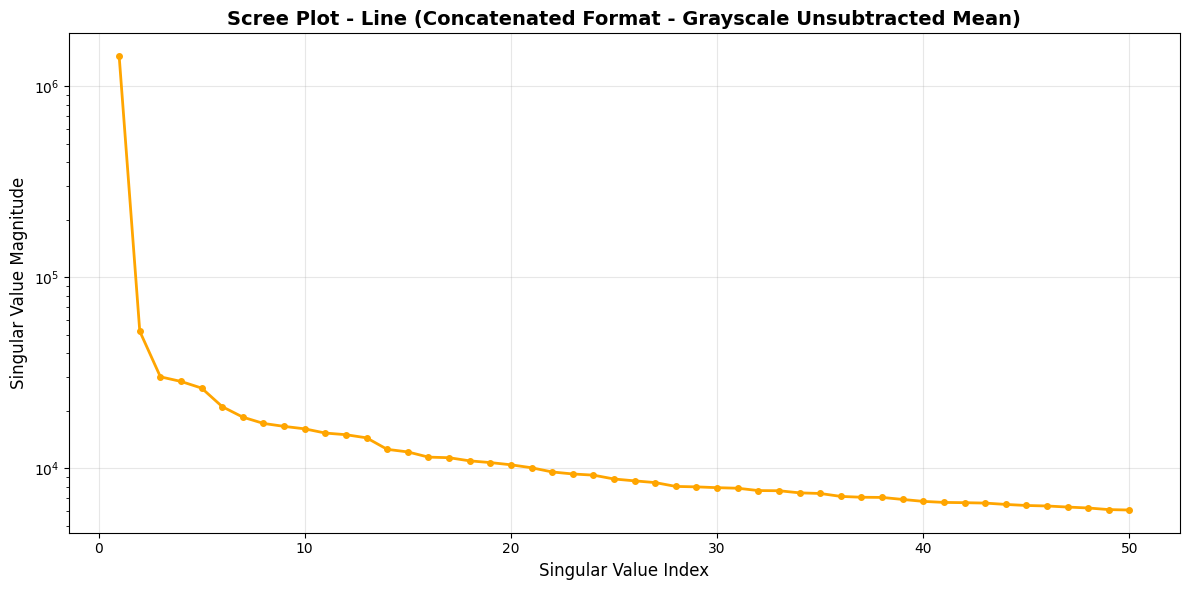

✓ Saved: Scree_Plot_03b_Concat_Gray_Unsub_Bar.png


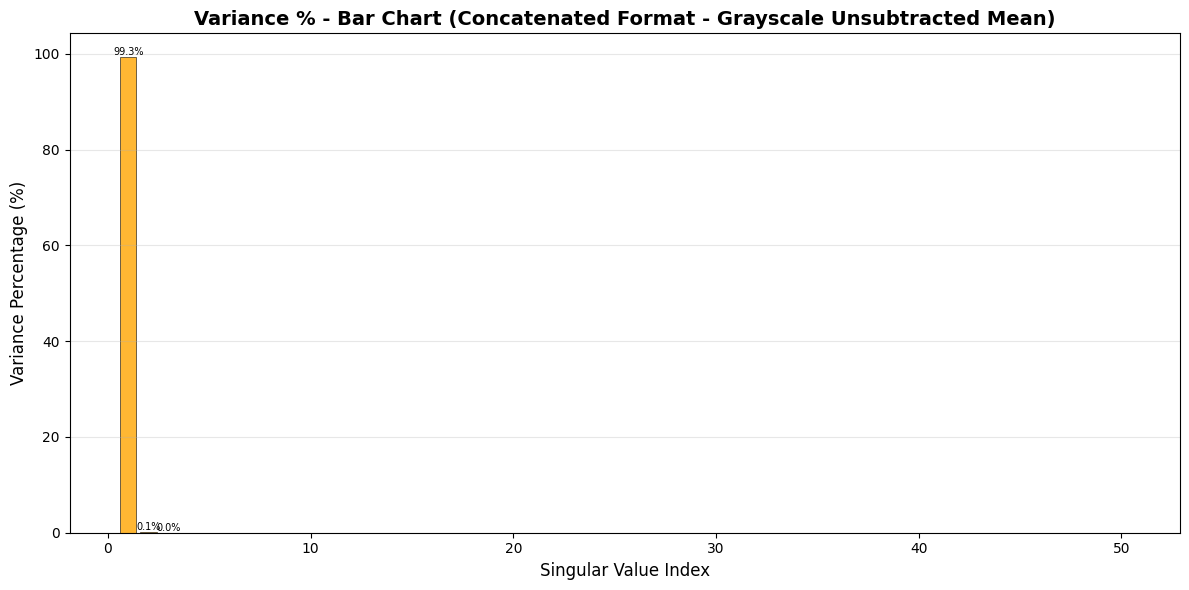

✓ Saved: Scree_Plot_04a_Native_PerChannel_Line.png


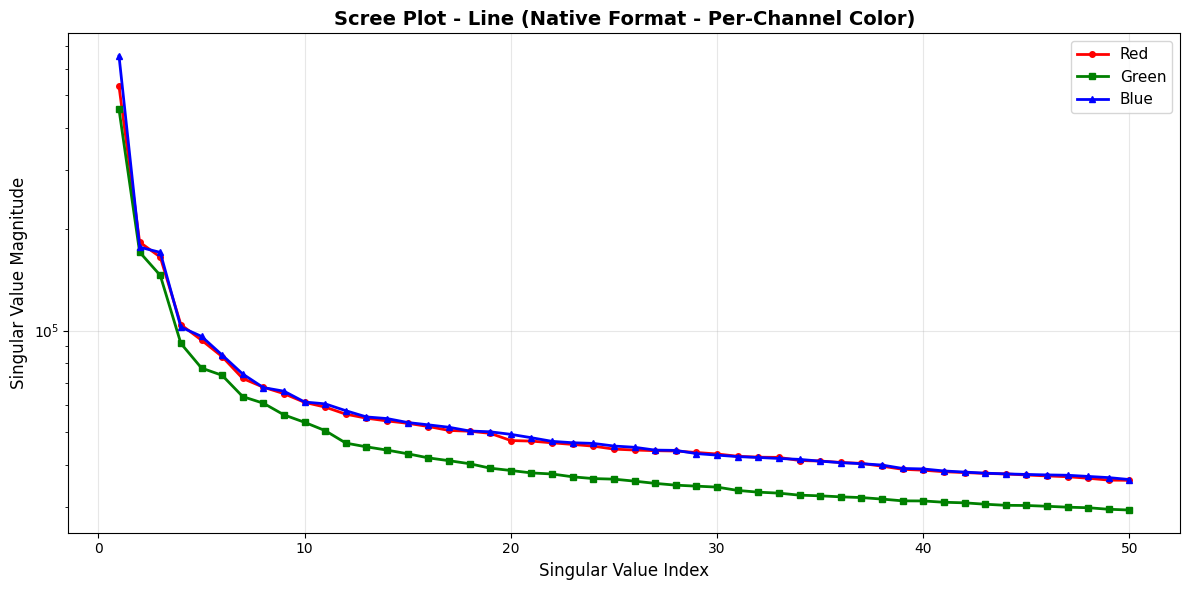

✓ Saved: Scree_Plot_04b_Native_PerChannel_Bar.png


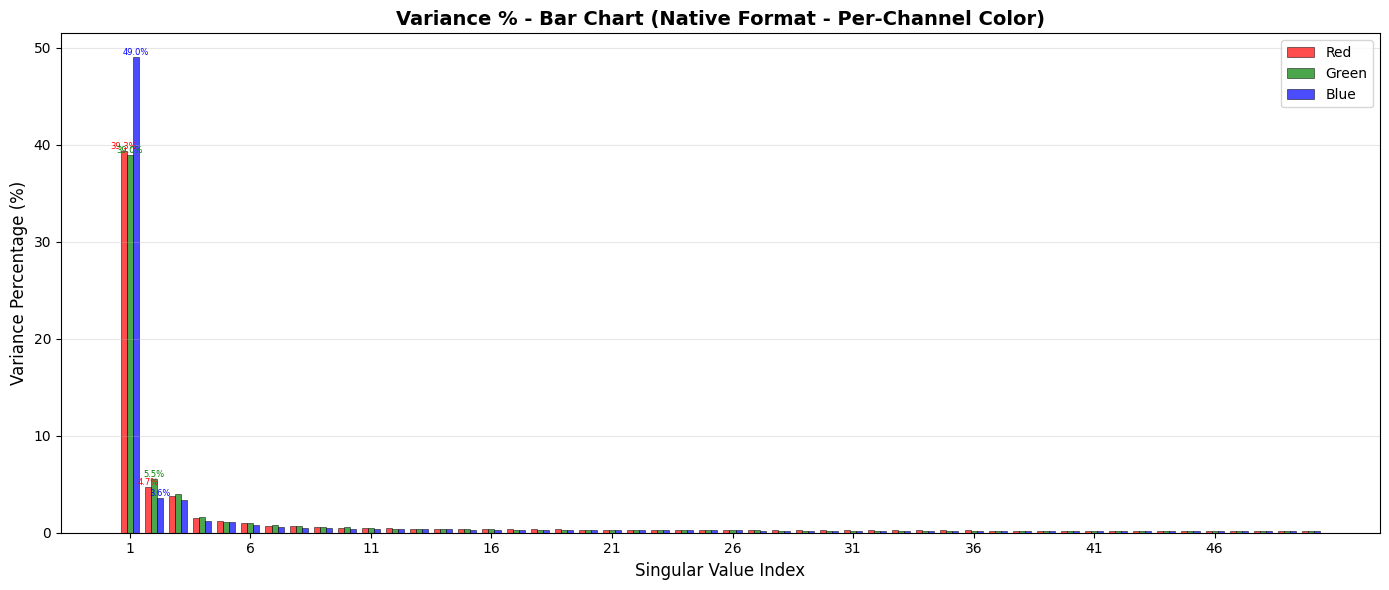

✓ Saved: Scree_Plot_05_Grayscale_Comparison.png


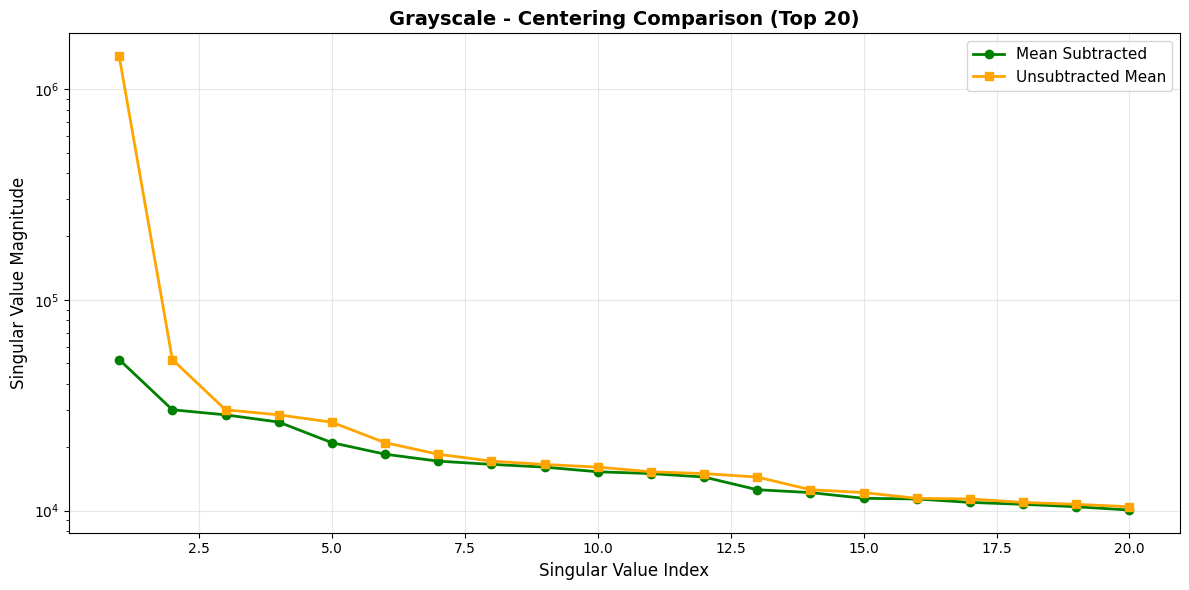

✓ Saved: Scree_Plot_06_All_Approaches.png


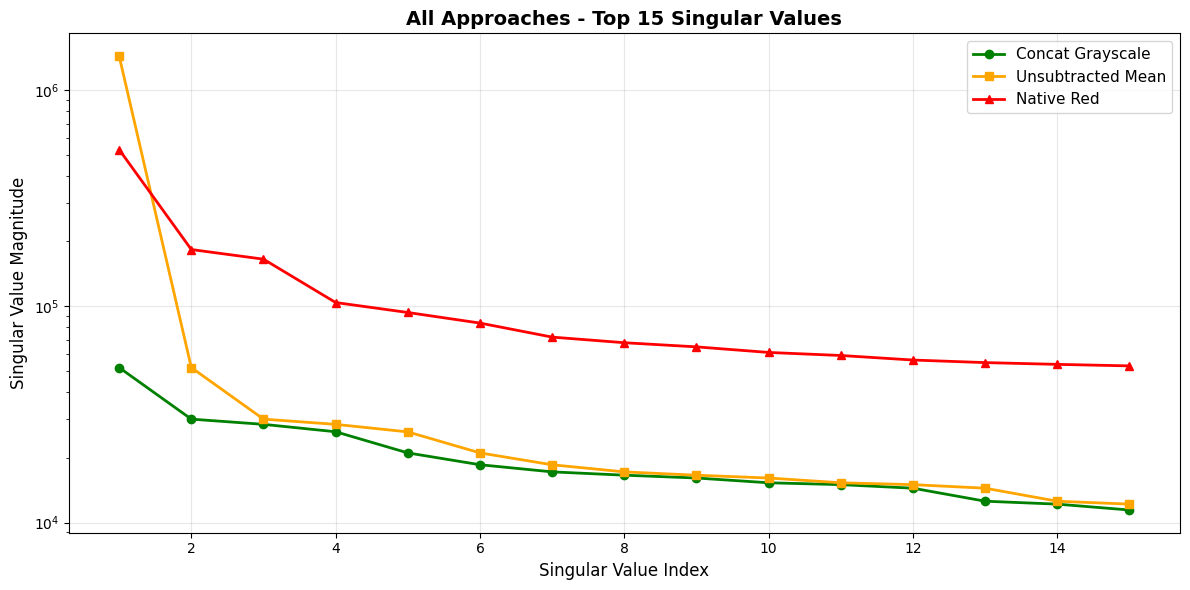


✓ All scree plots saved and displayed


In [11]:
import matplotlib.pyplot as plt
import numpy as np

print("CREATING AND SAVING SCREE PLOTS")

# =============== PLOT 1: Concatenated Color ===============

# Save line plot separately
fig1a, ax1a = plt.subplots(figsize=(12, 6))
ax1a.plot(range(1, min(51, len(S)+1)), S[:50], 'b-o', linewidth=2, markersize=4)
ax1a.set_title('Scree Plot - Line (Concatenated Format - Color)', fontsize=14, fontweight='bold')
ax1a.set_xlabel('Singular Value Index', fontsize=12)
ax1a.set_ylabel('Singular Value Magnitude', fontsize=12)
ax1a.grid(True, alpha=0.3)
ax1a.set_yscale('log')
plt.tight_layout()
filename1a = f"{output_dir}\\Scree_Plot_01a_Concat_Color_Line.png"
plt.savefig(filename1a, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_01a_Concat_Color_Line.png")
plt.show()

# Save bar plot separately
fig1b, ax1b = plt.subplots(figsize=(12, 6))
var_pct = (S[:50]**2) / np.sum(S**2) * 100
bars1 = ax1b.bar(range(1, min(51, len(S)+1)), var_pct, color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax1b.set_title('Variance % - Bar Chart (Concatenated Format - Color)', fontsize=14, fontweight='bold')
ax1b.set_xlabel('Singular Value Index', fontsize=12)
ax1b.set_ylabel('Variance Percentage (%)', fontsize=12)
ax1b.grid(True, alpha=0.3, axis='y')

# Add value labels on first 6 bars only
for i, (bar, vp) in enumerate(zip(bars1[:6], var_pct[:6])):
    height = bar.get_height()
    ax1b.text(bar.get_x() + bar.get_width()/2., height,
              f'{vp:.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
filename1b = f"{output_dir}\\Scree_Plot_01b_Concat_Color_Bar.png"
plt.savefig(filename1b, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_01b_Concat_Color_Bar.png")
plt.show()

# =============== PLOT 2: Concatenated Grayscale (Mean Subtracted) ===============

# Save line plot separately
fig2a, ax2a = plt.subplots(figsize=(12, 6))
ax2a.plot(range(1, min(51, len(S_gray)+1)), S_gray[:50], 'g-o', linewidth=2, markersize=4)
ax2a.set_title('Scree Plot - Line (Concatenated Format - Grayscale Mean Subtracted)', fontsize=14, fontweight='bold')
ax2a.set_xlabel('Singular Value Index', fontsize=12)
ax2a.set_ylabel('Singular Value Magnitude', fontsize=12)
ax2a.grid(True, alpha=0.3)
ax2a.set_yscale('log')
plt.tight_layout()
filename2a = f"{output_dir}\\Scree_Plot_02a_Concat_Gray_MeanSub_Line.png"
plt.savefig(filename2a, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_02a_Concat_Gray_MeanSub_Line.png")
plt.show()

# Save bar plot separately
fig2b, ax2b = plt.subplots(figsize=(12, 6))
var_pct_gray = (S_gray[:50]**2) / np.sum(S_gray**2) * 100
bars2 = ax2b.bar(range(1, min(51, len(S_gray)+1)), var_pct_gray, color='seagreen', alpha=0.8, edgecolor='black', linewidth=0.5)
ax2b.set_title('Variance % - Bar Chart (Concatenated Format - Grayscale Mean Subtracted)', fontsize=14, fontweight='bold')
ax2b.set_xlabel('Singular Value Index', fontsize=12)
ax2b.set_ylabel('Variance Percentage (%)', fontsize=12)
ax2b.grid(True, alpha=0.3, axis='y')

# Add value labels on first 6 bars only
for i, (bar, vp) in enumerate(zip(bars2[:6], var_pct_gray[:6])):
    height = bar.get_height()
    ax2b.text(bar.get_x() + bar.get_width()/2., height,
              f'{vp:.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
filename2b = f"{output_dir}\\Scree_Plot_02b_Concat_Gray_MeanSub_Bar.png"
plt.savefig(filename2b, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_02b_Concat_Gray_MeanSub_Bar.png")
plt.show()

# =============== PLOT 3: Concatenated Grayscale (Unsubtracted Mean) ===============

# Save line plot separately
fig3a, ax3a = plt.subplots(figsize=(12, 6))
ax3a.plot(range(1, min(51, len(S_gray_Unsubtracted_Mean)+1)), S_gray_Unsubtracted_Mean[:50],
          color='orange', marker='o', linewidth=2, markersize=4)
ax3a.set_title('Scree Plot - Line (Concatenated Format - Grayscale Unsubtracted Mean)', fontsize=14, fontweight='bold')
ax3a.set_xlabel('Singular Value Index', fontsize=12)
ax3a.set_ylabel('Singular Value Magnitude', fontsize=12)
ax3a.grid(True, alpha=0.3)
ax3a.set_yscale('log')
plt.tight_layout()
filename3a = f"{output_dir}\\Scree_Plot_03a_Concat_Gray_Unsub_Line.png"
plt.savefig(filename3a, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_03a_Concat_Gray_Unsub_Line.png")
plt.show()

# Save bar plot separately
fig3b, ax3b = plt.subplots(figsize=(12, 6))
var_pct_gray_unsub = (S_gray_Unsubtracted_Mean[:50]**2) / np.sum(S_gray_Unsubtracted_Mean**2) * 100
bars3 = ax3b.bar(range(1, min(51, len(S_gray_Unsubtracted_Mean)+1)), var_pct_gray_unsub, color='orange', alpha=0.8, edgecolor='black', linewidth=0.5)
ax3b.set_title('Variance % - Bar Chart (Concatenated Format - Grayscale Unsubtracted Mean)', fontsize=14, fontweight='bold')
ax3b.set_xlabel('Singular Value Index', fontsize=12)
ax3b.set_ylabel('Variance Percentage (%)', fontsize=12)
ax3b.grid(True, alpha=0.3, axis='y')

# Add value labels on first 3 bars only
for i, (bar, vp) in enumerate(zip(bars3[:3], var_pct_gray_unsub[:3])):
    height = bar.get_height()
    ax3b.text(bar.get_x() + bar.get_width()/2., height,
              f'{vp:.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
filename3b = f"{output_dir}\\Scree_Plot_03b_Concat_Gray_Unsub_Bar.png"
plt.savefig(filename3b, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_03b_Concat_Gray_Unsub_Bar.png")
plt.show()

# =============== PLOT 4: Native Format - Per-Channel Color ===============

# Save line plot separately
fig4a, ax4a = plt.subplots(figsize=(12, 6))
ax4a.plot(range(1, min(51, len(S_native_r)+1)), S_native_r[:50], 'r-o', linewidth=2, markersize=4, label='Red')
ax4a.plot(range(1, min(51, len(S_native_g)+1)), S_native_g[:50], 'g-s', linewidth=2, markersize=4, label='Green')
ax4a.plot(range(1, min(51, len(S_native_b)+1)), S_native_b[:50], 'b-^', linewidth=2, markersize=4, label='Blue')
ax4a.set_title('Scree Plot - Line (Native Format - Per-Channel Color)', fontsize=14, fontweight='bold')
ax4a.set_xlabel('Singular Value Index', fontsize=12)
ax4a.set_ylabel('Singular Value Magnitude', fontsize=12)
ax4a.legend(fontsize=11)
ax4a.grid(True, alpha=0.3)
ax4a.set_yscale('log')
plt.tight_layout()
filename4a = f"{output_dir}\\Scree_Plot_04a_Native_PerChannel_Line.png"
plt.savefig(filename4a, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_04a_Native_PerChannel_Line.png")
plt.show()

# Save bar plot separately
fig4b, ax4b = plt.subplots(figsize=(14, 6))
var_pct_r = (S_native_r[:50]**2)/np.sum(S_native_r**2)*100
var_pct_g = (S_native_g[:50]**2)/np.sum(S_native_g**2)*100
var_pct_b = (S_native_b[:50]**2)/np.sum(S_native_b**2)*100

x_pos = np.arange(min(50, len(S_native_r)))
width = 0.25

bars_r = ax4b.bar(x_pos - width, var_pct_r, width, label='Red', color='red', alpha=0.7, edgecolor='black', linewidth=0.5)
bars_g = ax4b.bar(x_pos, var_pct_g, width, label='Green', color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
bars_b = ax4b.bar(x_pos + width, var_pct_b, width, label='Blue', color='blue', alpha=0.7, edgecolor='black', linewidth=0.5)

ax4b.set_title('Variance % - Bar Chart (Native Format - Per-Channel Color)', fontsize=14, fontweight='bold')
ax4b.set_xlabel('Singular Value Index', fontsize=12)
ax4b.set_ylabel('Variance Percentage (%)', fontsize=12)
ax4b.set_xticks(x_pos[::5])
ax4b.set_xticklabels([str(i+1) for i in x_pos[::5]])
ax4b.legend(fontsize=10)
ax4b.grid(True, alpha=0.3, axis='y')

# Add value labels on first 2 bars of all channels
for bar, vp in zip(bars_r[:2], var_pct_r[:2]):
    height = bar.get_height()
    ax4b.text(bar.get_x() + bar.get_width()/2., height,
              f'{vp:.1f}%', ha='center', va='bottom', fontsize=6, color='red')
              
for bar, vp in zip(bars_g[:2], var_pct_g[:2]):
    height = bar.get_height()
    ax4b.text(bar.get_x() + bar.get_width()/2., height,
              f'{vp:.1f}%', ha='center', va='bottom', fontsize=6, color='green')
              
for bar, vp in zip(bars_b[:2], var_pct_b[:2]):
    height = bar.get_height()
    ax4b.text(bar.get_x() + bar.get_width()/2., height,
              f'{vp:.1f}%', ha='center', va='bottom', fontsize=6, color='blue')

plt.tight_layout()
filename4b = f"{output_dir}\\Scree_Plot_04b_Native_PerChannel_Bar.png"
plt.savefig(filename4b, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_04b_Native_PerChannel_Bar.png")
plt.show()

# =============== PLOT 5: Grayscale Centering Comparison ===============
fig5, ax5 = plt.subplots(figsize=(12, 6))
ax5.plot(range(1, min(21, len(S_gray)+1)), S_gray[:20], 'g-o', linewidth=2, markersize=6, label='Mean Subtracted')
ax5.plot(range(1, min(21, len(S_gray_Unsubtracted_Mean)+1)), S_gray_Unsubtracted_Mean[:20], 'orange', marker='s', linewidth=2, markersize=6, label='Unsubtracted Mean')
ax5.set_title('Grayscale - Centering Comparison (Top 20)', fontsize=14, fontweight='bold')
ax5.set_xlabel('Singular Value Index', fontsize=12)
ax5.set_ylabel('Singular Value Magnitude', fontsize=12)
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3)
ax5.set_yscale('log')

plt.tight_layout()
filename5 = f"{output_dir}\\Scree_Plot_05_Grayscale_Comparison.png"
plt.savefig(filename5, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_05_Grayscale_Comparison.png")
plt.show()

# =============== PLOT 6: All Approaches Comparison ===============
fig6, ax6 = plt.subplots(figsize=(12, 6))
ax6.plot(range(1, min(16, len(S_gray)+1)), S_gray[:15], 'g-o', linewidth=2, markersize=6, label='Concat Grayscale')
ax6.plot(range(1, min(16, len(S_gray_Unsubtracted_Mean)+1)), S_gray_Unsubtracted_Mean[:15], 'orange', marker='s', linewidth=2, markersize=6, label='Unsubtracted Mean')
ax6.plot(range(1, min(16, len(S_native_r)+1)), S_native_r[:15], 'r-^', linewidth=2, markersize=6, label='Native Red')
ax6.set_title('All Approaches - Top 15 Singular Values', fontsize=14, fontweight='bold')
ax6.set_xlabel('Singular Value Index', fontsize=12)
ax6.set_ylabel('Singular Value Magnitude', fontsize=12)
ax6.legend(fontsize=11)
ax6.grid(True, alpha=0.3)
ax6.set_yscale('log')

plt.tight_layout()
filename6 = f"{output_dir}\\Scree_Plot_06_All_Approaches.png"
plt.savefig(filename6, dpi=150, bbox_inches='tight')
print(f"✓ Saved: Scree_Plot_06_All_Approaches.png")

plt.show()


print("\n✓ All scree plots saved and displayed")